17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training RNN Model...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.5710 - loss: 0.6680 - val_accuracy: 0.7880 - val_loss: 0.4855
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.8409 - loss: 0.3766 - val_accuracy: 0.8094 - val_loss: 0.4398
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.9095 - loss: 0.2311 - val_accuracy: 0.8240 - val_loss: 0.4100

Training LSTM Model...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 98ms/step - accuracy: 0.6762 - loss: 0.5799 - val_accuracy: 0.8584 - val_loss: 0.3453
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - accuracy: 0.8933 - loss: 0.2708 - val_accuracy: 0.8590 - val_loss: 0.3207
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 103ms/step - accuracy: 0.9280 - loss: 0.1981 - val_accuracy: 0.8758 - val_loss: 0.3191

Training GRU Model...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 135ms/step - accuracy: 0.6513 - loss: 0.5977 - val_accuracy: 0.8490 - val_loss: 0.3557
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step - a

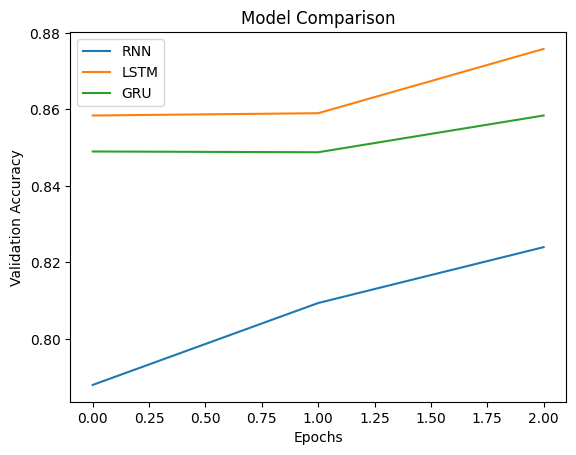


Test Accuracy
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8277 - loss: 0.4039
RNN: 0.8284000158309937
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8683 - loss: 0.3333
LSTM: 0.8680800199508667
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8498 - loss: 0.3970
GRU: 0.8508399724960327


In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load IMDb Dataset
# -------------------------------
vocab_size = 10000
maxlen = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

# -------------------------------
# 2. RNN Model
# -------------------------------
rnn_model = Sequential([
    Embedding(vocab_size, 32, input_length=maxlen),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

print("\nTraining RNN Model...")
rnn_history = rnn_model.fit(x_train, y_train,
                            epochs=3,
                            batch_size=64,
                            validation_split=0.2)

# -------------------------------
# 3. LSTM Model
# -------------------------------
lstm_model = Sequential([
    Embedding(vocab_size, 32, input_length=maxlen),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

print("\nTraining LSTM Model...")
lstm_history = lstm_model.fit(x_train, y_train,
                              epochs=3,
                              batch_size=64,
                              validation_split=0.2)

# -------------------------------
# 4. GRU Model
# -------------------------------
gru_model = Sequential([
    Embedding(vocab_size, 32, input_length=maxlen),
    GRU(32),
    Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

print("\nTraining GRU Model...")
gru_history = gru_model.fit(x_train, y_train,
                            epochs=3,
                            batch_size=64,
                            validation_split=0.2)

# -------------------------------
# 5. Compare Learning Curves
# -------------------------------
plt.plot(rnn_history.history['val_accuracy'], label='RNN')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM')
plt.plot(gru_history.history['val_accuracy'], label='GRU')

plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

# -------------------------------
# 6. Test Accuracy
# -------------------------------
print("\nTest Accuracy")

print("RNN:", rnn_model.evaluate(x_test, y_test)[1])
print("LSTM:", lstm_model.evaluate(x_test, y_test)[1])
print("GRU:", gru_model.evaluate(x_test, y_test)[1])